In [14]:
import geopandas as gpd
from eoflow.rivers import build_river_network_graph
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
river_gdf = gpd.read_file("hydro_rivers.gdf")

In [6]:
river_gdf.head(2)

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,Shape_Leng,geometry
0,20350404,20350777,20346222,0.69,36.099998,3.3,3.79,3.8,0,0.115,1,4,7,2.120407e+09,0.006250,"LINESTRING (-3.83542 50.926, -3.83542 50.92292)"
1,20350405,20350777,20346222,4.47,36.200001,6.8,12.31,12.3,0,0.369,1,3,7,2.120407e+09,0.053242,"LINESTRING (-3.83233 50.926, -3.83542 50.92292)"


In [7]:
graph = build_river_network_graph(river_gdf)

In [10]:
graph

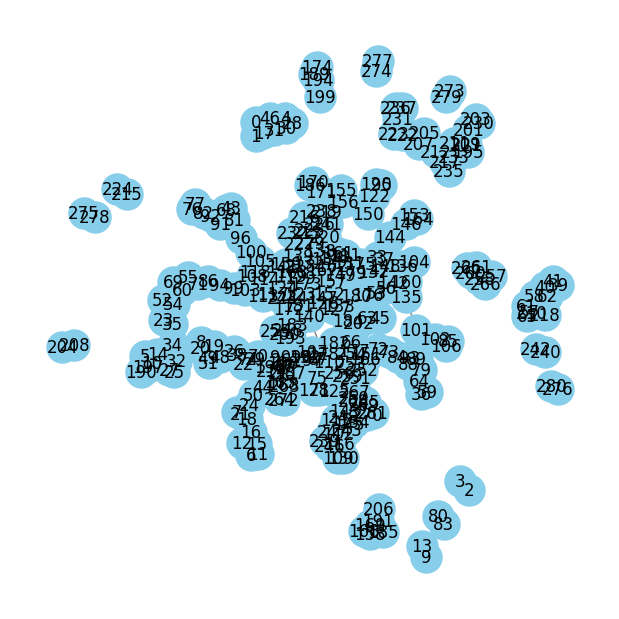

In [16]:
# Draw
plt.figure(figsize=(6, 6))
nx.draw(graph, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500)
plt.show()

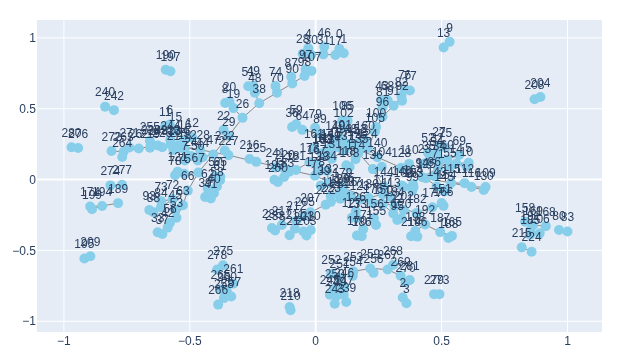

In [22]:
import plotly.graph_objects as go

pos = nx.spring_layout(graph)  # layout

# Edge traces
edge_x = []
edge_y = []
for edge in graph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(x=edge_x, y=edge_y,
                        line=dict(width=1, color='#888'),
                        hoverinfo='none',
                        mode='lines')

# Node traces
node_x = []
node_y = []
for node in graph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(x=node_x, y=node_y,
                        mode='markers+text',
                        hoverinfo='text',
                        marker=dict(color='skyblue', size=10),
                        text=[str(n) for n in graph.nodes()],
                        textposition="top center")

# Create figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(showlegend=False, margin=dict(t=20, b=20, l=20, r=20)))
fig.show()